In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [19]:
# Define project paths
BASE_DIR = Path(".").resolve().parent
print("Working directory:", BASE_DIR)
df_ratings = pd.read_csv(BASE_DIR / "data" / "processed" / "ratings_processed.csv")
df_anime = pd.read_csv(BASE_DIR / "data" / "processed" / "anime_merged.csv")

Working directory: C:\Users\CHAMPUX\Downloads\UPC TRABAJOS 2026\BIG DATA\proyect


In [20]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

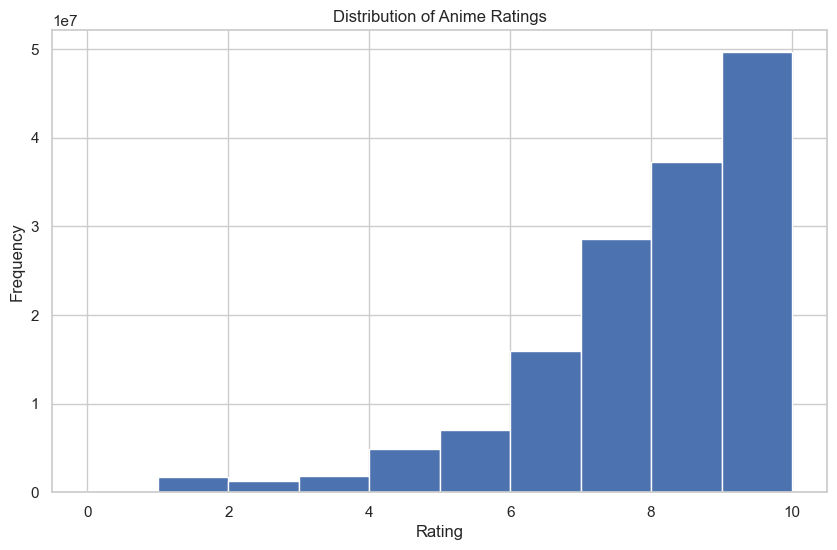

In [21]:
# Distribution of Anime Ratings
plt.figure()
plt.hist(df_ratings["rating"], bins=10)
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

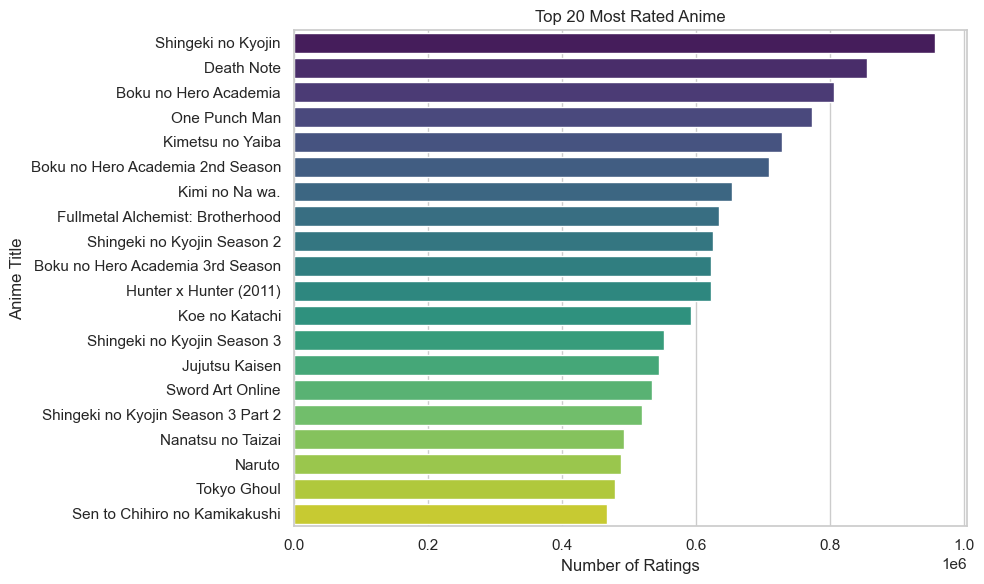

In [22]:
# Count ratings per anime
top_counts = df_ratings["animeID"].value_counts().head(20)

# Map animeID → title
id_to_title = df_anime.set_index("animeID")["title"].to_dict()

labels = [id_to_title.get(i, str(i)) for i in top_counts.index]

plt.figure()

sns.barplot(x=list(top_counts.values),y=list(labels),hue=list(labels),palette="viridis",legend=False)

plt.title("Top 20 Most Rated Anime")
plt.xlabel("Number of Ratings")
plt.ylabel("Anime Title")

plt.tight_layout()
plt.show()

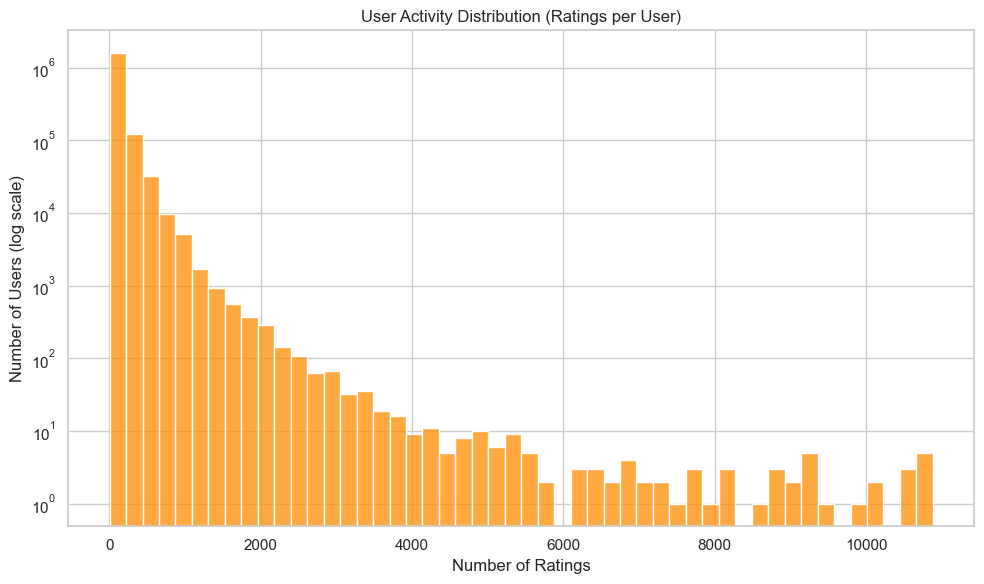

In [23]:
# Count ratings per user
user_counts = df_ratings["userID"].value_counts()

plt.figure()
sns.histplot(user_counts, bins=50, color="darkorange")

plt.yscale("log")

plt.title("User Activity Distribution (Ratings per User)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users (log scale)")

plt.tight_layout()
plt.show()

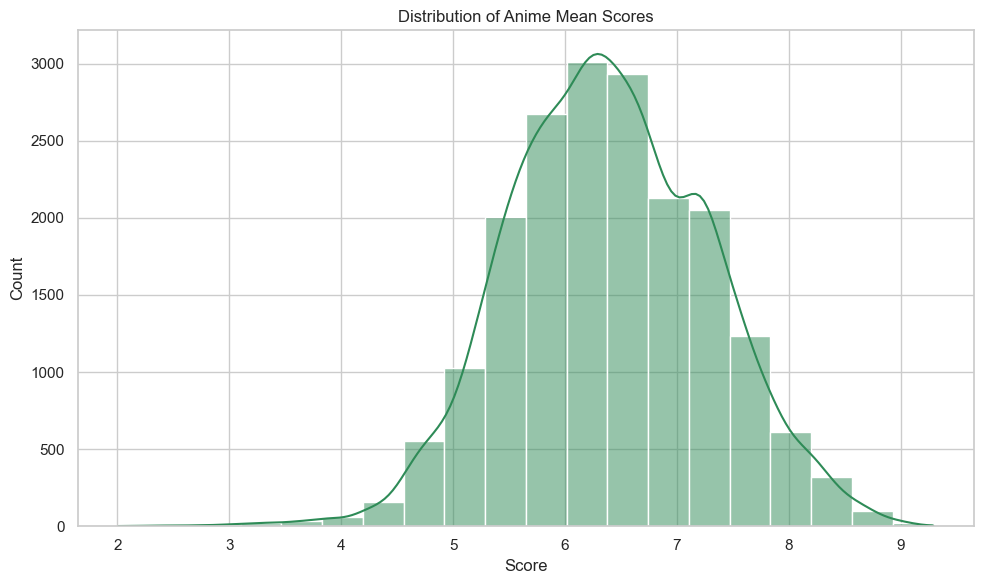

In [24]:
# Distribution of Anime Mean Scores
plt.figure()
sns.histplot(df_anime["mean_score"].dropna(), bins=20, kde=True, color="seagreen")

plt.title("Distribution of Anime Mean Scores")
plt.xlabel("Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

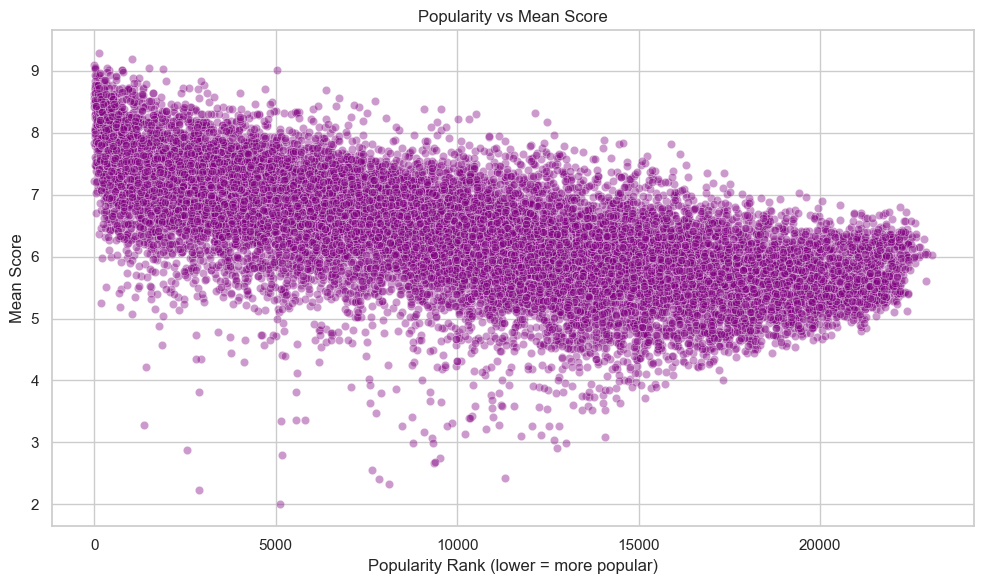

In [25]:
# Popularity vs Mean Score
plt.figure()

sns.scatterplot(
    data=df_anime,
    x="popularity",
    y="mean_score",
    alpha=0.4,
    color="purple"
)

plt.title("Popularity vs Mean Score")
plt.xlabel("Popularity Rank (lower = more popular)")
plt.ylabel("Mean Score")

plt.tight_layout()
plt.show()

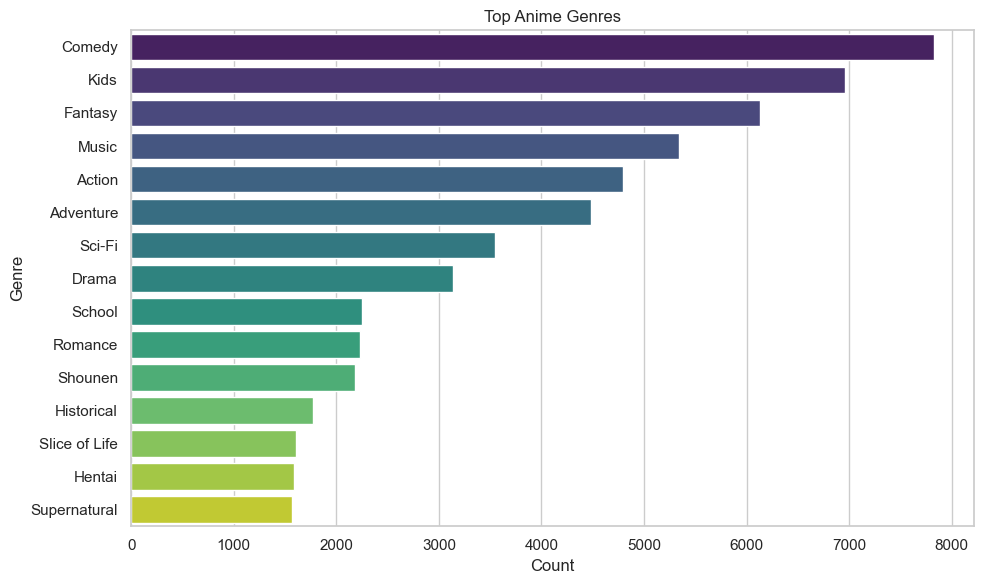

In [26]:
# Top Genres
from collections import Counter

genres_series = df_anime["genres"].dropna().str.split(",")

counter = Counter()
for g_list in genres_series:
    counter.update([g.strip() for g in g_list])

top_genres = counter.most_common(15)

genres, counts = zip(*top_genres)

plt.figure()

sns.barplot(x=list(counts),y=list(genres),hue=list(genres),palette="viridis",legend=False)

plt.title("Top Anime Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()